In [38]:
#Is there a relationship between the percentage of households using cars for transportation and the percentage of museums classified as art museums in North Carolina counties?

In [39]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [40]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv, find_dotenv

In [41]:
env_content = """
CENSUS_API_KEY=37d5985ad46bc17215096d5b16589ea3d45dada8
"""

with open(".env", "w") as f:
    f.write(env_content.strip())

print("📁 Brand new .env file force-created right next to your notebook!")
from dotenv import load_dotenv
print("Loading status:", load_dotenv(".env", override=True))


📁 Brand new .env file force-created right next to your notebook!
Loading status: True


In [42]:
load_dotenv()

True

In [43]:
api_key=os.getenv("CENSUS_API_KEY")

In [ ]:
print(api_key)

37d5985ad46bc17215096d5b16589ea3d45dada8
37d5985ad46bc17215096d5b16589ea3d45dada8


In [ ]:
url = f"https://api.census.gov/data/2024/acs/acs1?get=NAME,B01001_001E&for=county:*&in=state:37&key={api_key}"

In [46]:
response = requests.get(url)

In [47]:
response.text

'[["NAME","B01001_001E","state","county"],\n["Alamance County, North Carolina","183040","37","001"],\n["Brunswick County, North Carolina","167112","37","019"],\n["Buncombe County, North Carolina","279210","37","021"],\n["Burke County, North Carolina","88545","37","023"],\n["Cabarrus County, North Carolina","244925","37","025"],\n["Caldwell County, North Carolina","80739","37","027"],\n["Carteret County, North Carolina","70259","37","031"],\n["Catawba County, North Carolina","167054","37","035"],\n["Chatham County, North Carolina","83874","37","037"],\n["Cleveland County, North Carolina","102194","37","045"],\n["Craven County, North Carolina","104167","37","049"],\n["Cumberland County, North Carolina","338430","37","051"],\n["Davidson County, North Carolina","177809","37","057"],\n["Durham County, North Carolina","343628","37","063"],\n["Forsyth County, North Carolina","398143","37","067"],\n["Franklin County, North Carolina","79771","37","069"],\n["Gaston County, North Carolina","24201

In [48]:
data = response.json()

In [49]:
data

[['NAME', 'B01001_001E', 'state', 'county'],
 ['Alamance County, North Carolina', '183040', '37', '001'],
 ['Brunswick County, North Carolina', '167112', '37', '019'],
 ['Buncombe County, North Carolina', '279210', '37', '021'],
 ['Burke County, North Carolina', '88545', '37', '023'],
 ['Cabarrus County, North Carolina', '244925', '37', '025'],
 ['Caldwell County, North Carolina', '80739', '37', '027'],
 ['Carteret County, North Carolina', '70259', '37', '031'],
 ['Catawba County, North Carolina', '167054', '37', '035'],
 ['Chatham County, North Carolina', '83874', '37', '037'],
 ['Cleveland County, North Carolina', '102194', '37', '045'],
 ['Craven County, North Carolina', '104167', '37', '049'],
 ['Cumberland County, North Carolina', '338430', '37', '051'],
 ['Davidson County, North Carolina', '177809', '37', '057'],
 ['Durham County, North Carolina', '343628', '37', '063'],
 ['Forsyth County, North Carolina', '398143', '37', '067'],
 ['Franklin County, North Carolina', '79771', '37'

In [50]:
dfcsv = pd.read_csv(r"C:\Users\allis\Downloads\nc_county_art_pct.csv")

dfcsv.head()

,county,percent_art_museum,museum_count,art_museum_count
0,Alamance,0.0,11,0
1,Alexander,0.0,3,0
2,Alleghany,0.0,2,0
3,Anson,0.0,2,0
4,Ashe,0.0,4,0


In [62]:
variables = ",".join([
    "NAME",            # County name
    "B01003_001E",     # Total population
    "B08141_001E",     # Total: Means of Transportation to Work by Vehicles Available (People that drive)
    "B08141_016E",     # Estimate!!Total:!!Public transportation:
    "B08141_017E",     # Estimate!!Total:!!Public transportation:!!No vehicle available
    "B08141_021E",     #Estimate!!Total:!!Walked:

])

url = f"https://api.census.gov/data/2024/acs/acs1?get={variables}&for=county:*&in=state:37&key={api_key}"

response = requests.get(url)

data = response.json()

df = pd.DataFrame(data[1:], columns=data[0])

df

,NAME,B01003_001E,B08141_001E,B08141_016E,B08141_017E,B08141_021E,state,county
0,"Alamance County, North Carolina",183040,87390,353,0,1298,37,001
1,"Brunswick County, North Carolina",167112,None,None,None,None,37,019
2,"Buncombe County, North Carolina",279210,129951,367,0,2047,37,021
3,"Burke County, North Carolina",88545,None,None,None,None,37,023
4,"Cabarrus County, North Carolina",244925,122994,990,0,1378,37,025
5,"Caldwell County, North Carolina",80739,None,None,None,None,37,027
6,"Carteret County, North Carolina",70259,None,None,None,None,37,031
7,"Catawba County, North Carolina",167054,None,None,None,None,37,035
8,"Chatham County, North Carolina",83874,None,None,None,None,37,037
9,"Cleveland County, North Carolina",102194,None,None,None,None,37,045


In [63]:
df.to_csv("census_data.csv", index=False)

df.head()

,NAME,B01003_001E,B08141_001E,B08141_016E,B08141_017E,B08141_021E,state,county
0,"Alamance County, North Carolina",183040,87390,353,0,1298,37,001
1,"Brunswick County, North Carolina",167112,None,None,None,None,37,019
2,"Buncombe County, North Carolina",279210,129951,367,0,2047,37,021
3,"Burke County, North Carolina",88545,None,None,None,None,37,023
4,"Cabarrus County, North Carolina",244925,122994,990,0,1378,37,025


In [76]:
df = df.rename(columns={
    #"NAME": "County_Name",
    "B01003_001E": "Total_Population",
    "B08141_001E": "Total_Transp_By_Vehicles_Available",
    "B08141_016E": "Total_Public_Transp",
    "B08141_017E": "No_Vehicle_Available",
    "B08141_021E": "Walks"
})

df.head()

,NAME,Total_Population,Total Transportation By Vehicles Available,Total Public Transportation,No_Vehicle_Available,Walked,state,county
0,Alamance,183040,87390,353,0,1298,37,001
1,Brunswick,167112,None,None,None,None,37,019
2,Buncombe,279210,129951,367,0,2047,37,021
3,Burke,88545,None,None,None,None,37,023
4,Cabarrus,244925,122994,990,0,1378,37,025


In [71]:
County_names = list(df['NAME'])
counties = list(dfcsv['county'])



In [73]:

filtered_list = [item.split(" County")[0] for item in County_names]


In [74]:
dfcsv_filtered = dfcsv[dfcsv['county'].isin(filtered_list)]

print(dfcsv_filtered)

len(dfcsv_filtered)

df['NAME'] = filtered_list

         county  percent_art_museum  museum_count  art_museum_count
0      Alamance                0.00            11                 0
9     Brunswick                0.00             7                 0
10     Buncombe                8.00            25                 2
11        Burke                0.00             9                 0
12     Cabarrus                0.00             8                 0
13     Caldwell               14.29             7                 1
14     Carteret                0.00             9                 0
16      Catawba                6.67            15                 1
17      Chatham               25.00             4                 1
21    Cleveland                0.00             7                 0
23       Craven                7.69            13                 1
24   Cumberland                5.26            19                 1
27     Davidson               14.29             7                 1
30       Durham               11.54            2

In [75]:
len(df)
df.head()

,NAME,Total_Population,Total Transportation By Vehicles Available,Total Public Transportation,No_Vehicle_Available,Walked,state,county
0,Alamance,183040,87390,353,0,1298,37,001
1,Brunswick,167112,None,None,None,None,37,019
2,Buncombe,279210,129951,367,0,2047,37,021
3,Burke,88545,None,None,None,None,37,023
4,Cabarrus,244925,122994,990,0,1378,37,025


In [77]:


df: pd.DataFrame = df.merge(
    right = dfcsv_filtered, # The other dataframe we would like to merge on 
    left_on = ["NAME"], # The names of the column in the left dataframe we would like to merge on
    right_on = ["county"], # The names of the column in the right dataframe we would like to merge on
    how = "right" # The type of merge
)

df.head()

,NAME,Total_Population,Total Transportation By Vehicles Available,Total Public Transportation,No_Vehicle_Available,Walked,state,county_x,county_y,percent_art_museum,museum_count,art_museum_count
0,Alamance,183040,87390,353,0,1298,37,001,Alamance,0.0,11,0
1,Brunswick,167112,None,None,None,None,37,019,Brunswick,0.0,7,0
2,Buncombe,279210,129951,367,0,2047,37,021,Buncombe,8.0,25,2
3,Burke,88545,None,None,None,None,37,023,Burke,0.0,9,0
4,Cabarrus,244925,122994,990,0,1378,37,025,Cabarrus,0.0,8,0


In [78]:
df.isnull().sum()

NAME                                           0
Total_Population                               0
Total Transportation By Vehicles Available    26
Total Public Transportation                   26
No_Vehicle_Available                          26
Walked                                        26
state                                          0
county_x                                       0
county_y                                       0
percent_art_museum                             0
museum_count                                   0
art_museum_count                               0
dtype: int64

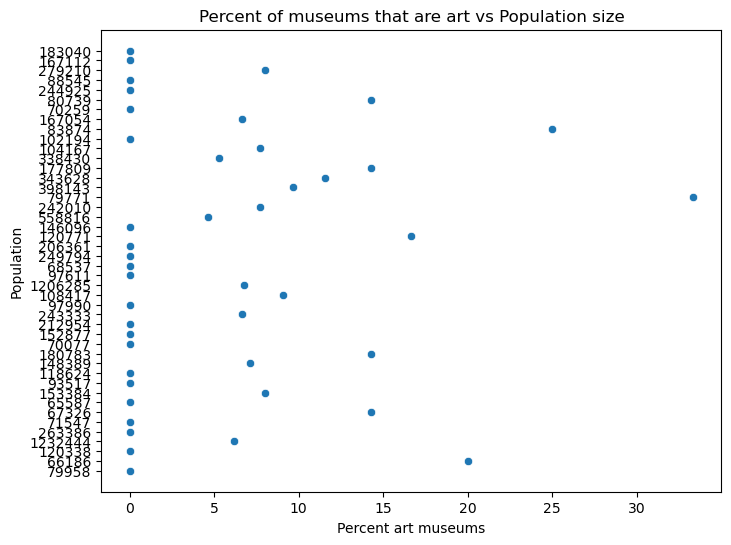

In [85]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="percent_art_museum", y="Total_Population")
plt.title("Percent of museums that are art vs Population size")
plt.xlabel("Percent art museums")
plt.ylabel("Population")
plt.show()

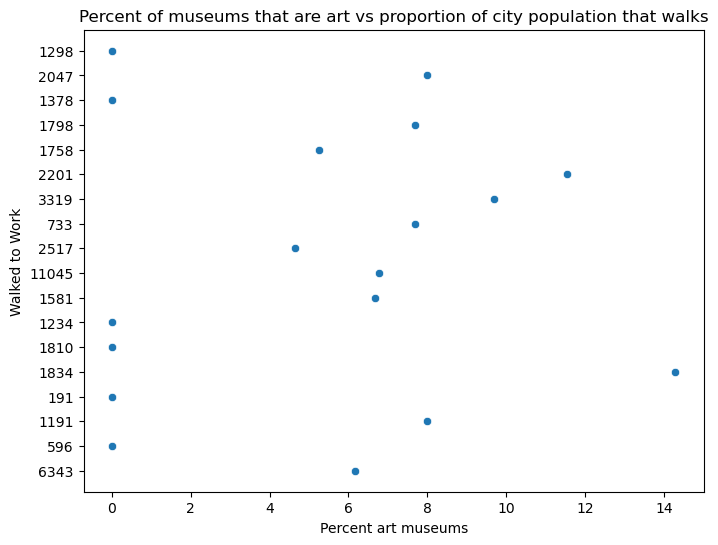

In [82]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="percent_art_museum", y="Walked")
plt.title("Percent of museums that are art vs proportion of city population that walks")
plt.xlabel("Percent art museums")
plt.ylabel("Walked to Work")
plt.show()

In [ ]:
dfboth = pd.merge(df, dfcsv, on="NAME") #combines the data sets using the shared variable of county name so I can use variables from both for my visualization

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=dfboth, x="Total Public Transportation", y="Walked")
plt.title("Total Public Transportation vs Walked to Work (NC Counties)")
plt.xlabel("Total Public Transportation")
plt.ylabel("Walked to Work")
plt.show()

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df[""], bins=20)
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()